# Experiment: Noise Distribution in Non-Vascular Region

## Objective
- Characterize the intensity distribution (histogram + PDF + CDF) in the **non-vascular** region.
- Estimate noise statistics in that region.
- Test a first noise injection strategy to increase variability.

## Success Criteria
- Reproducible comparison of the original non-vascular distribution versus a noise-injected version.


In [32]:
from __future__ import annotations

from pathlib import Path
import math

import matplotlib.pyplot as plt
import nibabel as nib
import nibabel.processing as nibproc
import numpy as np

SEED = 42
rng = np.random.default_rng(SEED)

# -------- Main configuration --------
IMAGE_PATH = Path('data/paired_dataset/lr_3t/001_20240313/input_mag_raw.nii.gz')
VASCULAR_MASK_PATH = Path('data/paired_dataset/cow_segmentation/001_20240313/cow_seg_final.nii.gz')
ANALYSIS_MASK_PATH = Path('data/paired_dataset/cow_segmentation/001_20240313/analysis_mask.nii.gz')
USE_ANALYSIS_MASK = True

MASK_THRESHOLD = 0.5
TIME_MODE = 'all'      # 'all' or 'frame'
FRAME_INDEX = 0        # used only when TIME_MODE='frame'

HIST_BINS = 160
EXCLUDE_ZERO_INTENSITY = True
ZERO_EPS = 1e-8
CLIP_TO_PERCENTILES = (0.5, 99.5)  # set to None to disable clipping
MAX_SAMPLES_FOR_PLOT = 600_000

# -------- Noise injection configuration --------
NOISE_TYPE = 'gaussian'  # 'gaussian' or 'rician'
NOISE_SIGMA_FACTOR = 1.0 # multiplier on estimated non-vascular sigma


In [33]:
def resolve_input_path(path: Path) -> Path:
    path = Path(path)
    if path.exists():
        return path
    if not path.is_absolute():
        alt = Path('..') / path
        if alt.exists():
            return alt
    return path


def load_nifti_float(path: Path) -> tuple[nib.Nifti1Image, np.ndarray]:
    resolved = resolve_input_path(path)
    if not resolved.exists():
        raise FileNotFoundError(f'Missing file: {path} (resolved: {resolved.resolve()})')
    img = nib.load(str(resolved))
    arr = np.asarray(img.dataobj, dtype=np.float32)
    return img, arr


def select_mask_3d(mask_data: np.ndarray, time_index: int = 0) -> np.ndarray:
    if mask_data.ndim == 3:
        return mask_data
    if mask_data.ndim == 4:
        if not (0 <= time_index < mask_data.shape[-1]):
            raise ValueError(f'time_index={time_index} is out of range for mask shape={mask_data.shape}')
        return np.asarray(mask_data[..., time_index], dtype=np.float32)
    raise ValueError(f'Invalid mask shape={mask_data.shape}. Expected 3D or 4D.')


def align_mask_to_reference(mask_img: nib.Nifti1Image, mask_3d: np.ndarray, ref_img: nib.Nifti1Image) -> np.ndarray:
    mask_3d_img = nib.Nifti1Image(mask_3d, mask_img.affine, mask_img.header)
    same_shape = tuple(mask_3d_img.shape[:3]) == tuple(ref_img.shape[:3])
    same_affine = np.allclose(mask_3d_img.affine, ref_img.affine, atol=1e-4)
    if not (same_shape and same_affine):
        mask_3d_img = nibproc.resample_from_to(mask_3d_img, (ref_img.shape[:3], ref_img.affine), order=0)
    return np.asarray(mask_3d_img.dataobj, dtype=np.float32)


def to_binary_mask(mask_data: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    return (mask_data >= float(threshold)).astype(np.uint8)


def clean_values(values: np.ndarray, exclude_zeros: bool = True, zero_eps: float = 1e-8) -> np.ndarray:
    x = np.asarray(values, dtype=np.float64).ravel()
    x = x[np.isfinite(x)]
    if exclude_zeros:
        x = x[np.abs(x) > float(zero_eps)]
    return x


def aligned_clean_pair(
    values_a: np.ndarray,
    values_b: np.ndarray,
    exclude_zeros: bool = True,
    zero_eps: float = 1e-8,
) -> tuple[np.ndarray, np.ndarray]:
    a = np.asarray(values_a, dtype=np.float64).ravel()
    b = np.asarray(values_b, dtype=np.float64).ravel()
    if a.shape != b.shape:
        raise ValueError(f'Input arrays must have the same shape: {a.shape} vs {b.shape}')

    keep = np.isfinite(a) & np.isfinite(b)
    if exclude_zeros:
        keep &= np.abs(a) > float(zero_eps)

    return a[keep], b[keep]


def extract_region_values(
    image_data: np.ndarray,
    region_mask_3d: np.ndarray,
    time_mode: str = 'all',
    frame_index: int = 0,
) -> np.ndarray:
    mask_bool = region_mask_3d.astype(bool)

    if image_data.ndim == 3:
        return image_data[mask_bool]

    if image_data.ndim != 4:
        raise ValueError(f'Expected 3D/4D image, got shape={image_data.shape}')

    if time_mode == 'frame':
        if not (0 <= frame_index < image_data.shape[-1]):
            raise ValueError(f'frame_index={frame_index} is out of range for shape={image_data.shape}')
        return image_data[..., frame_index][mask_bool]

    if time_mode != 'all':
        raise ValueError("time_mode must be 'all' or 'frame'")

    return image_data[mask_bool].reshape(-1)


def summarize_distribution(values: np.ndarray) -> dict[str, float]:
    x = np.asarray(values, dtype=np.float64)
    if x.size == 0:
        return {
            'count': 0,
            'mean': np.nan,
            'std': np.nan,
            'median': np.nan,
            'mad': np.nan,
            'robust_sigma': np.nan,
            'p01': np.nan,
            'p05': np.nan,
            'p50': np.nan,
            'p95': np.nan,
            'p99': np.nan,
            'skewness': np.nan,
            'excess_kurtosis': np.nan,
            'snr_median_over_sigma': np.nan,
        }

    mean = float(np.mean(x))
    std = float(np.std(x, ddof=0))
    median = float(np.median(x))
    mad = float(np.median(np.abs(x - median)))
    robust_sigma = 1.4826 * mad

    if std > 0:
        z = (x - mean) / std
        skewness = float(np.mean(z ** 3))
        excess_kurtosis = float(np.mean(z ** 4) - 3.0)
    else:
        skewness = np.nan
        excess_kurtosis = np.nan

    snr = float(np.abs(median) / robust_sigma) if robust_sigma > 0 else np.nan

    return {
        'count': int(x.size),
        'mean': mean,
        'std': std,
        'median': median,
        'mad': mad,
        'robust_sigma': robust_sigma,
        'p01': float(np.percentile(x, 1)),
        'p05': float(np.percentile(x, 5)),
        'p50': float(np.percentile(x, 50)),
        'p95': float(np.percentile(x, 95)),
        'p99': float(np.percentile(x, 99)),
        'skewness': skewness,
        'excess_kurtosis': excess_kurtosis,
        'snr_median_over_sigma': snr,
    }


def maybe_clip(values: np.ndarray, clip_percentiles: tuple[float, float] | None) -> np.ndarray:
    x = np.asarray(values, dtype=np.float64)
    if clip_percentiles is None:
        return x
    lo, hi = np.percentile(x, clip_percentiles)
    return np.clip(x, lo, hi)


def downsample_for_plot(values: np.ndarray, max_samples: int, rng_local: np.random.Generator) -> np.ndarray:
    x = np.asarray(values)
    if x.size <= max_samples:
        return x
    idx = rng_local.choice(x.size, size=max_samples, replace=False)
    return x[idx]


def compute_hist_pdf_cdf(values: np.ndarray, bins: int, vmin: float, vmax: float):
    counts, edges = np.histogram(values, bins=bins, range=(vmin, vmax), density=False)
    widths = np.diff(edges)
    total = max(counts.sum(), 1)
    probs = counts / total
    pdf = probs / widths
    cdf = np.cumsum(probs)
    centers = edges[:-1] + widths / 2.0
    return counts, centers, pdf, cdf


def js_divergence_from_counts(counts_a: np.ndarray, counts_b: np.ndarray, eps: float = 1e-12) -> float:
    p = counts_a.astype(np.float64) + eps
    q = counts_b.astype(np.float64) + eps
    p /= p.sum()
    q /= q.sum()
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * np.log(p / m))
    kl_qm = np.sum(q * np.log(q / m))
    return float(0.5 * (kl_pm + kl_qm))


In [34]:
img, image_data = load_nifti_float(IMAGE_PATH)
vascular_img, vascular_raw = load_nifti_float(VASCULAR_MASK_PATH)

vascular_3d = select_mask_3d(vascular_raw, time_index=0)
vascular_3d = align_mask_to_reference(vascular_img, vascular_3d, img)
vascular_mask = to_binary_mask(vascular_3d, threshold=MASK_THRESHOLD)

if USE_ANALYSIS_MASK:
    analysis_img, analysis_raw = load_nifti_float(ANALYSIS_MASK_PATH)
    analysis_3d = select_mask_3d(analysis_raw, time_index=0)
    analysis_3d = align_mask_to_reference(analysis_img, analysis_3d, img)
    analysis_mask = to_binary_mask(analysis_3d, threshold=MASK_THRESHOLD)
else:
    analysis_mask = np.ones(img.shape[:3], dtype=np.uint8)

nonvascular_mask = ((analysis_mask > 0) & (vascular_mask == 0)).astype(np.uint8)

print('Image path:', IMAGE_PATH)
print('Image shape:', image_data.shape)
print('Vascular mask shape:', vascular_mask.shape)
print('Analysis mask voxels:', int(analysis_mask.sum()))
print('Non-vascular voxels:', int(nonvascular_mask.sum()))


Image path: data/paired_dataset/lr_3t/001_20240313/input_mag_raw.nii.gz
Image shape: (147, 99, 48, 9)
Vascular mask shape: (147, 99, 48)
Analysis mask voxels: 698544
Non-vascular voxels: 682967


In [35]:
nonvascular_values_raw = extract_region_values(
    image_data,
    nonvascular_mask,
    time_mode=TIME_MODE,
    frame_index=FRAME_INDEX,
)

nonvascular_values = clean_values(
    nonvascular_values_raw,
    exclude_zeros=EXCLUDE_ZERO_INTENSITY,
    zero_eps=ZERO_EPS,
)

if nonvascular_values.size == 0:
    raise ValueError('No valid voxels found in the non-vascular region. Check masks and settings.')

nonvascular_values_for_plot = maybe_clip(nonvascular_values, CLIP_TO_PERCENTILES)
stats_nonvascular = summarize_distribution(nonvascular_values)

print('---- Non-vascular noise statistics ----')
for k, v in stats_nonvascular.items():
    print(f'{k:>24}: {v}')


---- Non-vascular noise statistics ----
                   count: 6146703
                    mean: 209.80949717949719
                     std: 73.44548415949174
                  median: 200.3430938720703
                     mad: 45.58062744140625
            robust_sigma: 67.57783824462891
                     p01: 79.10055770874024
                     p05: 107.61513061523438
                     p50: 200.3430938720703
                     p95: 343.5451385498045
                     p99: 427.61010192871083
                skewness: 0.9249259622509843
         excess_kurtosis: 1.9646604692055325
   snr_median_over_sigma: 2.9646271481315636


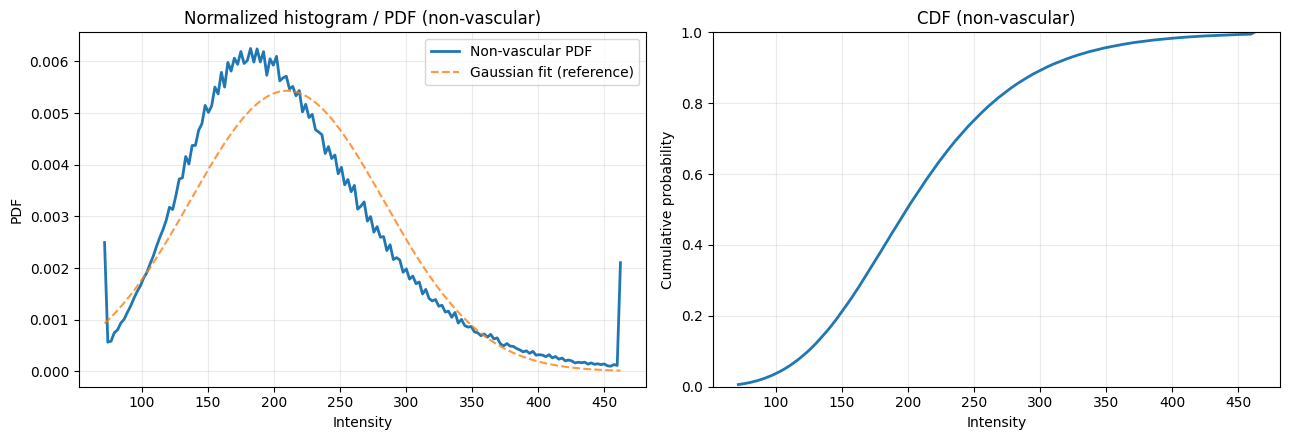

In [36]:
plot_nonvascular = downsample_for_plot(nonvascular_values_for_plot, MAX_SAMPLES_FOR_PLOT, rng)

vmin = float(np.min(plot_nonvascular))
vmax = float(np.max(plot_nonvascular))

counts_nv, centers_nv, pdf_nv, cdf_nv = compute_hist_pdf_cdf(plot_nonvascular, HIST_BINS, vmin, vmax)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(centers_nv, pdf_nv, label='Non-vascular PDF', linewidth=2)

mu = stats_nonvascular['mean']
sigma = stats_nonvascular['std']
if np.isfinite(mu) and np.isfinite(sigma) and sigma > 0:
    normal_pdf = (1.0 / (sigma * math.sqrt(2 * math.pi))) * np.exp(-0.5 * ((centers_nv - mu) / sigma) ** 2)
    axes[0].plot(centers_nv, normal_pdf, '--', label='Gaussian fit (reference)', alpha=0.8)

axes[0].set_title('Normalized histogram / PDF (non-vascular)')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('PDF')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(centers_nv, cdf_nv, label='Non-vascular CDF', linewidth=2)
axes[1].set_title('CDF (non-vascular)')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Cumulative probability')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [37]:
def add_noise(image: np.ndarray, sigma: float, mode: str, rng_local: np.random.Generator) -> np.ndarray:
    if sigma <= 0:
        return image.copy()

    n1 = rng_local.normal(0.0, sigma, size=image.shape).astype(np.float32)

    if mode == 'gaussian':
        return (image + n1).astype(np.float32)

    if mode == 'rician':
        n2 = rng_local.normal(0.0, sigma, size=image.shape).astype(np.float32)
        return np.sqrt((image + n1) ** 2 + n2 ** 2).astype(np.float32)

    raise ValueError("NOISE_TYPE must be 'gaussian' or 'rician'")


sigma_base = stats_nonvascular['robust_sigma']
if not np.isfinite(sigma_base) or sigma_base <= 0:
    sigma_base = stats_nonvascular['std']

sigma_injected = float(NOISE_SIGMA_FACTOR * sigma_base)
image_noisy = add_noise(image_data, sigma=sigma_injected, mode=NOISE_TYPE, rng_local=rng)

noisy_nonvascular_raw = extract_region_values(
    image_noisy,
    nonvascular_mask,
    time_mode=TIME_MODE,
    frame_index=FRAME_INDEX,
)
noisy_nonvascular = clean_values(
    noisy_nonvascular_raw,
    exclude_zeros=EXCLUDE_ZERO_INTENSITY,
    zero_eps=ZERO_EPS,
)
noisy_nonvascular_for_plot = maybe_clip(noisy_nonvascular, CLIP_TO_PERCENTILES)

stats_noisy = summarize_distribution(noisy_nonvascular)

print(f'NOISE_TYPE={NOISE_TYPE}')
print(f'sigma_base (estimated): {sigma_base:.6g}')
print(f'sigma_injected: {sigma_injected:.6g}')
print()
print('---- Non-vascular statistics after injected noise ----')
for k, v in stats_noisy.items():
    print(f'{k:>24}: {v}')


NOISE_TYPE=gaussian
sigma_base (estimated): 67.5778
sigma_injected: 67.5778

---- Non-vascular statistics after injected noise ----
                   count: 6146703
                    mean: 209.8437559979558
                     std: 99.83130421877374
                  median: 204.806396484375
                     mad: 65.28921508789062
            robust_sigma: 96.79779028930663
                     p01: -2.615143127441403
                     p05: 55.423326873779295
                     p50: 204.806396484375
                     p95: 380.9944427490234
                     p99: 470.88243408203095
                skewness: 0.367773680549593
         excess_kurtosis: 0.5765001596934778
   snr_median_over_sigma: 2.1158168577222183


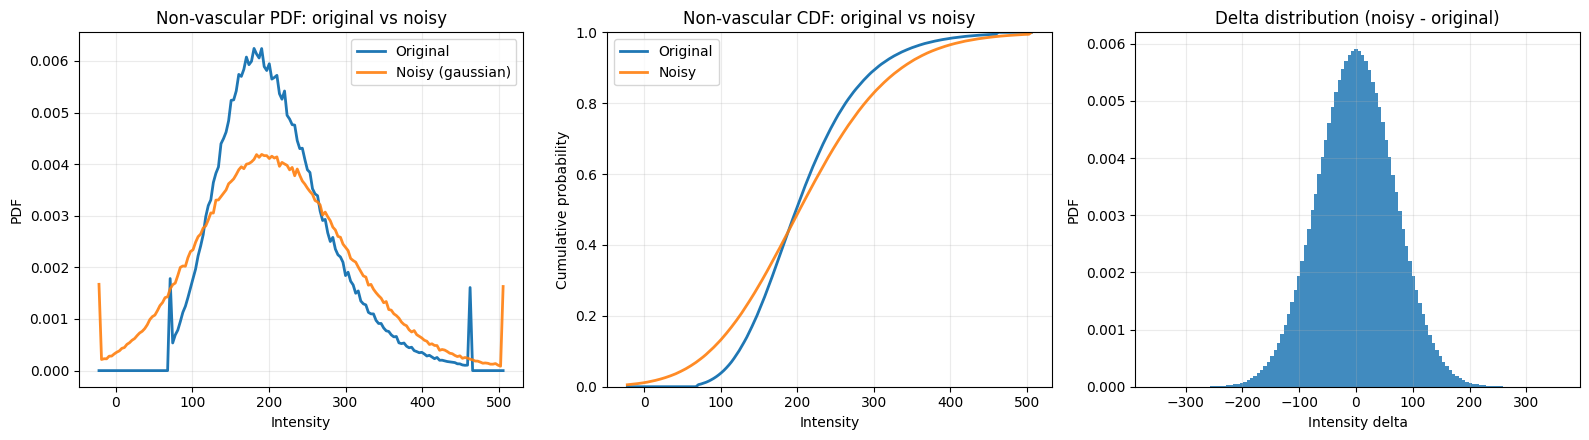

Jensen-Shannon divergence (original vs noisy): 0.041555
Delta mean: 0.0342588
Delta std : 67.5627


In [38]:
plot_orig = downsample_for_plot(nonvascular_values_for_plot, MAX_SAMPLES_FOR_PLOT, rng)
plot_noisy = downsample_for_plot(noisy_nonvascular_for_plot, MAX_SAMPLES_FOR_PLOT, rng)

vmin_cmp = float(min(np.min(plot_orig), np.min(plot_noisy)))
vmax_cmp = float(max(np.max(plot_orig), np.max(plot_noisy)))

counts_orig, centers_orig, pdf_orig, cdf_orig = compute_hist_pdf_cdf(plot_orig, HIST_BINS, vmin_cmp, vmax_cmp)
counts_noisy, centers_noisy, pdf_noisy, cdf_noisy = compute_hist_pdf_cdf(plot_noisy, HIST_BINS, vmin_cmp, vmax_cmp)

jsd = js_divergence_from_counts(counts_orig, counts_noisy)

orig_delta_base, noisy_delta_base = aligned_clean_pair(
    nonvascular_values_raw,
    noisy_nonvascular_raw,
    exclude_zeros=EXCLUDE_ZERO_INTENSITY,
    zero_eps=ZERO_EPS,
)
delta_values = noisy_delta_base - orig_delta_base

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(centers_orig, pdf_orig, label='Original', linewidth=2)
axes[0].plot(centers_noisy, pdf_noisy, label=f'Noisy ({NOISE_TYPE})', linewidth=2, alpha=0.9)
axes[0].set_title('Non-vascular PDF: original vs noisy')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('PDF')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(centers_orig, cdf_orig, label='Original', linewidth=2)
axes[1].plot(centers_noisy, cdf_noisy, label='Noisy', linewidth=2, alpha=0.9)
axes[1].set_title('Non-vascular CDF: original vs noisy')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Cumulative probability')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].hist(delta_values, bins=120, density=True, alpha=0.85)
axes[2].set_title('Delta distribution (noisy - original)')
axes[2].set_xlabel('Intensity delta')
axes[2].set_ylabel('PDF')
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f'Jensen-Shannon divergence (original vs noisy): {jsd:.6f}')
print(f'Delta mean: {np.mean(delta_values):.6g}')
print(f'Delta std : {np.std(delta_values):.6g}')


## Recommended Next Steps
1. Sweep `NOISE_SIGMA_FACTOR` (for example: `0.5, 1.0, 1.5, 2.0`) and track the Jensen-Shannon divergence.
2. Repeat across cases (`001...007`) and modalities (3T / 7T) to estimate robust augmentation ranges.
3. Use those ranges to define a training augmentation policy (for example, Gaussian/Rician mixture sampling).
